<a href="https://colab.research.google.com/github/springboardmentor2468a-lab/Projects_2/blob/Humera/Week_3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# TASK 1: Import necessary libraries

from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

plt.rcParams['figure.figsize'] = (10, 5)
sns.set(style="whitegrid")

In [2]:
from google.colab import files
import pandas as pd

uploaded = files.upload()   # Upload both hour.csv and day.csv together

hour_df = pd.read_csv("hour.csv")
day_df  = pd.read_csv("day.csv")

print(hour_df.shape)
print(day_df.shape)


Saving day.csv to day.csv
Saving hour.csv to hour.csv
(17379, 17)
(731, 16)


In [3]:
# Quick peek

display(Markdown("### Hour dataset head"))
display(hour_df.head())
display(Markdown("### Day dataset head"))
display(day_df.head())

### Hour dataset head

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Day dataset head

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
# TASK 3: Basic Cleaning and Feature Removal

print("\n===== BASIC CLEANING =====")

def basic_clean(df, name):
    print(f"\n{name} Shape: {df.shape}")
    print(f"Null Values:\n{df.isnull().sum()}")
    print("Duplicate rows:", df.duplicated().sum())

    # Normalize column names
    df.columns = [c.strip() for c in df.columns]

    # Preview dteday parsing
    if 'dteday' in df.columns:
        parsed = pd.to_datetime(df['dteday'], errors='coerce')
        print("Parsed dteday count:", parsed.notna().sum())

    return df

hour_df = basic_clean(hour_df, "hour_df")
day_df  = basic_clean(day_df,  "day_df")


# ✅ Remove unnecessary columns (Feature Removal)

columns_to_drop_day = ['instant', 'dteday', 'yr', 'casual', 'registered']
columns_to_drop_hour = ['instant', 'dteday', 'yr', 'casual', 'registered']

day_df.drop(columns=columns_to_drop_day, inplace=True, errors='ignore')
hour_df.drop(columns=columns_to_drop_hour, inplace=True, errors='ignore')

print("\nColumns removed successfully.")


# ✅ Show updated info

print("\n===== hour_df.info() =====")
hour_df.info()

print("\n===== day_df.info() =====")
day_df.info()

display(Markdown("### Cleaned Hour Dataset"))
display(hour_df.head())
display(Markdown("### Cleaned Day Dataset"))
display(day_df.head())



===== BASIC CLEANING =====

hour_df Shape: (17379, 17)
Null Values:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Duplicate rows: 0
Parsed dteday count: 17379

day_df Shape: (731, 16)
Null Values:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Duplicate rows: 0
Parsed dteday count: 731

Columns removed successfully.

===== hour_df.info() =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 

### Cleaned Hour Dataset

,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


### Cleaned Day Dataset

,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,1,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,1,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,1,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


In [5]:
print(hour_df.isnull().sum())

season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


In [6]:
print(day_df.isnull().sum())


season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


In [7]:
print("Hour dataset shape:", hour_df.shape)
print("Day dataset shape:", day_df.shape)

Hour dataset shape: (17379, 12)
Day dataset shape: (731, 11)



===== OUTLIER REMOVAL USING IQR =====


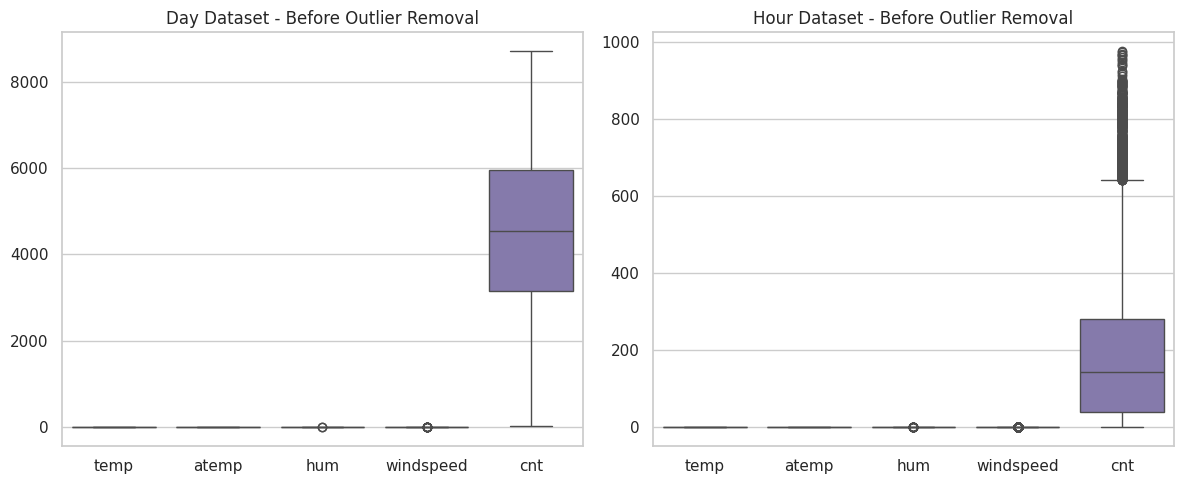

In [8]:
# TASK 4: Outlier Detection & Removal (IQR Method)

print("\n===== OUTLIER REMOVAL USING IQR =====")

# Select numeric columns
numeric_cols = ['temp','atemp','hum','windspeed','cnt']
numeric_day  = [c for c in numeric_cols if c in day_df.columns]
numeric_hour = [c for c in numeric_cols if c in hour_df.columns]

def remove_outliers(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    return df_clean

#Boxplot before removal
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=day_df[numeric_day])
plt.title("Day Dataset - Before Outlier Removal")

plt.subplot(1,2,2)
sns.boxplot(data=hour_df[numeric_hour])
plt.title("Hour Dataset - Before Outlier Removal")

plt.tight_layout()
plt.show()



Day dataset rows before: 731 | after: 717
Hour dataset rows before: 17379 | after: 16535


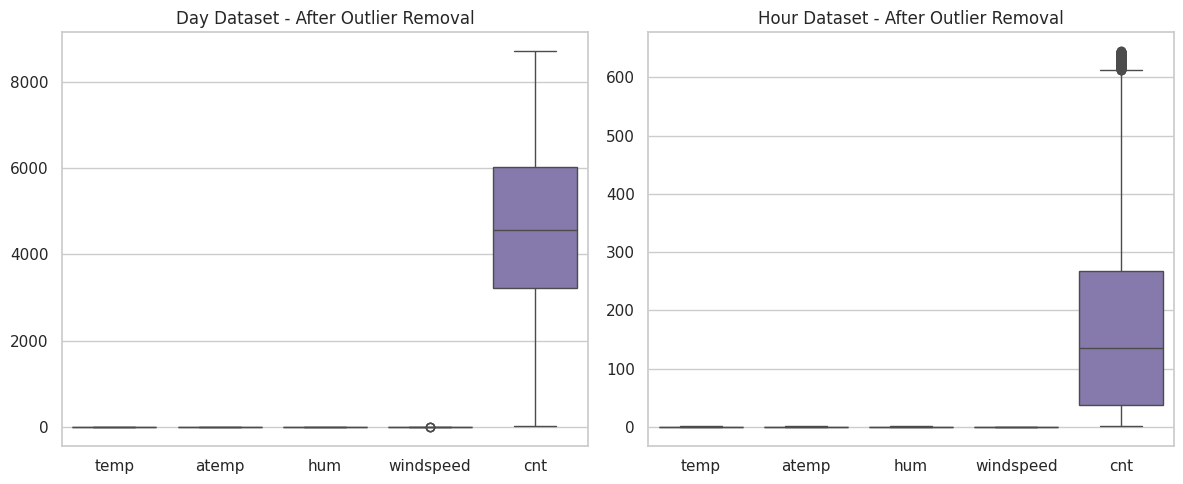


✅ Outlier removal completed.


In [9]:
# Apply outlier removal
day_before = day_df.shape[0]
hour_before = hour_df.shape[0]

day_df = remove_outliers(day_df, numeric_day)
hour_df = remove_outliers(hour_df, numeric_hour)

day_after = day_df.shape[0]
hour_after = hour_df.shape[0]

print("\nDay dataset rows before:", day_before, "| after:", day_after)
print("Hour dataset rows before:", hour_before, "| after:", hour_after)

# Boxplot after removal
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=day_df[numeric_day])
plt.title("Day Dataset - After Outlier Removal")

plt.subplot(1,2,2)
sns.boxplot(data=hour_df[numeric_hour])
plt.title("Hour Dataset - After Outlier Removal")

plt.tight_layout()
plt.show()

print("\nOutlier removal completed.")

In [37]:
# TASK 5: MODEL TRAINING WEEK 3

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#Day dataset

In [48]:
X_day = day_df.drop("cnt", axis=1)
y_day = day_df["cnt"]

# Train-test split
X_train_day, X_test_day, y_train_day, y_test_day = train_test_split(X_day, y_day, test_size=0.2, random_state=42)

print("Train shape:", X_train_day.shape)
print("Test shape:", X_test_day.shape)

# Scaling
scaler_day = StandardScaler()
X_train_day_scaled = scaler_day.fit_transform(X_train_day)
X_test_day_scaled = scaler_day.transform(X_test_day)

# Linear Regression
lr_day = LinearRegression()
lr_day.fit(X_train_day_scaled, y_train_day)
day_lr_pred = lr_day.predict(X_test_day_scaled)

print("\nDAY DATASET — Linear Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test_day, day_lr_pred)))
print("MAE :", mean_absolute_error(y_test_day, day_lr_pred))
print("R² :", r2_score(y_test_day, day_lr_pred))

rf_day = RandomForestRegressor(n_estimators=200, random_state=42)
rf_day.fit(X_train_day, y_train_day)
day_rf_pred = rf_day.predict(X_test_day)

print("\nDAY DATASET — Random Forest")
print("RMSE:", np.sqrt(mean_squared_error(y_test_day, day_rf_pred)))
print("MAE :", mean_absolute_error(y_test_day, day_rf_pred))
print("R² :", r2_score(y_test_day, day_rf_pred))


Train shape: (573, 10)
Test shape: (144, 10)

DAY DATASET — Linear Regression
RMSE: 1270.8645153745358
MAE : 1075.671781912195
R² : 0.5711801210459297

DAY DATASET — Random Forest
RMSE: 1150.2214523436014
MAE : 968.1814930555556
R² : 0.6487314006748115


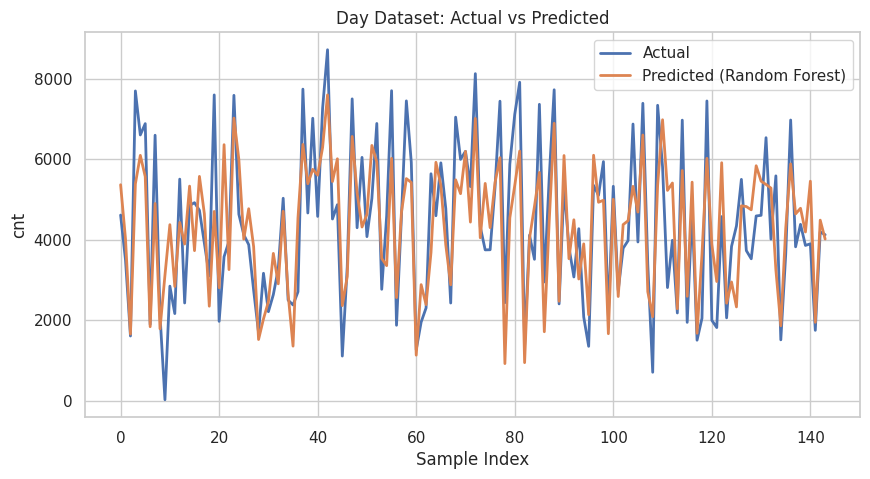

In [40]:
plt.figure(figsize=(10,5))
plt.plot(y_test_day.values, label="Actual", linewidth=2)
plt.plot(day_rf_pred, label="Predicted (Random Forest)", linewidth=2)
plt.title("Day Dataset: Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("cnt")
plt.legend()
plt.show()


#Hour Dataset

In [49]:
X_hour = hour_df.drop("cnt", axis=1)
y_hour = hour_df["cnt"]

# Train-test split
X_train_hr, X_test_hr, y_train_hr, y_test_hr = train_test_split(
    X_hour, y_hour, test_size=0.2, random_state=42
)

print("Train shape:", X_train_hr.shape)
print("Test shape:", X_test_hr.shape)

# Scaling
scaler_hr = StandardScaler()
X_train_hr_scaled = scaler_hr.fit_transform(X_train_hr)
X_test_hr_scaled = scaler_hr.transform(X_test_hr)

# Linear Regression
lr_hour = LinearRegression()
lr_hour.fit(X_train_hr_scaled, y_train_hr)
hr_lr_pred = lr_hour.predict(X_test_hr_scaled)

print("\nHOUR DATASET — Linear Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test_hr, hr_lr_pred)))
print("MAE :", mean_absolute_error(y_test_hr, hr_lr_pred))
print("R² :", r2_score(y_test_hr, hr_lr_pred))

# Random Forest
rf_hour = RandomForestRegressor(n_estimators=200, random_state=42)
rf_hour.fit(X_train_hr, y_train_hr)
hr_rf_pred = rf_hour.predict(X_test_hr)

print("\n HOUR DATASET — Random Forest")
print("RMSE:", np.sqrt(mean_squared_error(y_test_hr, hr_rf_pred)))
print("MAE :", mean_absolute_error(y_test_hr, hr_rf_pred))
print("R² :", r2_score(y_test_hr, hr_rf_pred))

Train shape: (13228, 11)
Test shape: (3307, 11)

HOUR DATASET — Linear Regression
RMSE: 120.7503321283933
MAE : 92.18121007563586
R² : 0.384399006940927

 HOUR DATASET — Random Forest
RMSE: 58.75337097683813
MAE : 39.05499051434907
R² : 0.8542568263103368


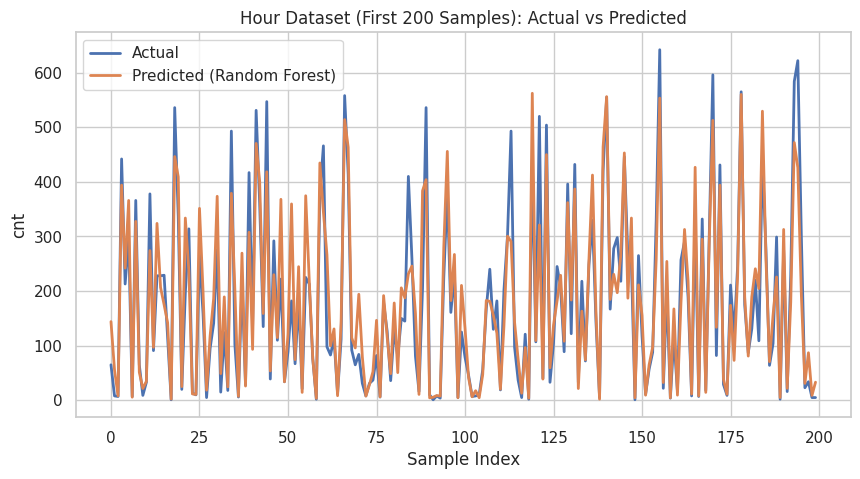

In [47]:
# Plot first 200 values for clarity
plt.figure(figsize=(10, 5))
plt.plot(y_test_hr.values[:200], label='Actual', linewidth=2)
plt.plot(hr_rf_pred[:200], label='Predicted (Random Forest)', linewidth=2)
plt.title("Hour Dataset (First 200 Samples): Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("cnt")
plt.legend()
plt.show()
